In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_curve,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             roc_auc_score, average_precision_score,
                             accuracy_score, classification_report)

# Load ABCA4 annotated mutation data
df = pd.read_csv('ABCA4_mutations_annotated_with_features.csv')

# Load AlphaMissense scores and merge into main dataset
alphamissense_df = pd.read_csv('ABCA4_alphamissense_scores.csv')
df = df.merge(
    alphamissense_df[['Variant', 'AlphaMissense_score', 'AlphaMissense_class']],
    on='Variant',
    how='left'
)

# Keep only rows with available AlphaMissense scores
df = df.dropna(subset=['AlphaMissense_score'])

print(df.shape) # (num_rows, num_cols)
print() # for spacing between outputs
print(df.head()) # first 5 rows of ABCA4 df
print()
print(df.dtypes) # data types of column values
print()
print(df['Significance'].value_counts()) # target label distribution
print()
print(df.isnull().sum()) # check if any null values exist in dataset
print()
print(df.info()) # shows dtypes, null counts, and shapes all in one


(3915, 139)

  Variant Significance   Source   Annotation  Position  Covalent  VDWClash  \
0     M1V   Pathogenic  ClinVar  Severe (10)         1         0         0   
1     M1L   Pathogenic  ClinVar  Unannotated         1         0         0   
2     M1T   Pathogenic  ClinVar  Unannotated         1         0         0   
3     M1I   Pathogenic  ClinVar  Unannotated         1         0         0   
4    L10F       Benign   gnomAD  Unannotated        10         0         2   

   VDW  Proximal  Hbond  ...  Demask_matrix  Demask_log2f_var  Demask_entropy  \
0    0        15      0  ...        -0.1978          -21.6186          0.0305   
1    0        15      0  ...        -0.1126           -8.3308          0.0305   
2    0        15      0  ...        -0.2263          -21.6186          0.0305   
3    0        15      0  ...        -0.1558          -21.6186          0.0305   
4    2       108      2  ...        -0.2003          -22.0190          0.0001   

   Consurf_score  MTR_score  IU

In [3]:
# filter to known labels only
df_known = df[df['Significance'].isin(['Benign', 'Pathogenic'])].copy()

print("Shape after filtering:", df_known.shape)
print("Class distribution:\n", df_known['Significance'].value_counts())

# separate out VUS for later prediction
df_vus = df[df['Significance'] == 'VUS'].copy()
print("\nVUS rows set aside:", df_vus.shape)

# Use Position only for grouped splitting; exclude it from model features
groups = df_known['Position']
X = df_known.drop(columns=['Variant', 'Significance', 'Source', 'Annotation', 'Position', 'AlphaMissense_score', 'AlphaMissense_class'], errors='ignore')
y = df_known['Significance']

Shape after filtering: (3103, 139)
Class distribution:
 Significance
Benign        1803
Pathogenic    1300
Name: count, dtype: int64

VUS rows set aside: (812, 139)


In [4]:
# split into train set, and temp set (for dev set and test set split later)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()
groups_temp = groups.iloc[temp_idx].copy()

# split temp set into dev and test set
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
dev_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_dev = X_temp.iloc[dev_idx].copy()
y_dev = y_temp.iloc[dev_idx].copy()

X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

print("Shape of X_train:", X_train.shape)
print("Shape of X_dev:", X_dev.shape)
print("Shape of X_test:", X_test.shape)

print("\nOriginal Proportion:\n", y.value_counts(normalize=True).round(3))
print("\nTrain Proportion:\n", y_train.value_counts(normalize=True).round(3))

Shape of X_train: (2179, 132)
Shape of X_dev: (473, 132)
Shape of X_test: (451, 132)

Original Proportion:
 Significance
Benign        0.581
Pathogenic    0.419
Name: proportion, dtype: float64

Train Proportion:
 Significance
Benign        0.583
Pathogenic    0.417
Name: proportion, dtype: float64


In [5]:
# Filter highly correlated features using training data only
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
print(f"Dropping {len(to_drop_corr)} highly correlated features due to Pearson > 0.90:")
print(to_drop_corr)

X_train = X_train.drop(columns=to_drop_corr)
X_dev = X_dev.drop(columns=to_drop_corr)
X_test = X_test.drop(columns=to_drop_corr)

print(f"\nRemaining features after correlation filter: {X_train.shape[1]}")

Dropping 66 highly correlated features due to Pearson > 0.90:
['d_Covalent', 'd_Ionic', 'HP_12_00', 'HH:11.50', 'PP:11.50', 'HP:11.50', 'HH:11.00', 'PP:11.00', 'HP:11.00', 'HH:10.50', 'PP:10.50', 'HP:10.50', 'HH:10.00', 'PP:10.00', 'HP:10.00', 'HH:9.50', 'PP:9.50', 'HP:9.50', 'HH:9.00', 'PP:9.00', 'HP:9.00', 'HH:8.50', 'PP:8.50', 'HP:8.50', 'HH:8.00', 'PP:8.00', 'HP:8.00', 'HH:7.50', 'PP:7.50', 'HP:7.50', 'HH:7.00', 'PP:7.00', 'HP:7.00', 'HH:6.50', 'PP:6.50', 'HP:6.50', 'HH:6.00', 'PP:6.00', 'HP:6.00', 'HH:5.50', 'PP:5.50', 'HP:5.50', 'HH:5.00', 'PP:5.00', 'HP:5.00', 'HH:4.50', 'PP:4.50', 'HP:4.50', 'HH:4.00', 'PP:4.00', 'HP:4.00', 'HH:3.50', 'PP:3.50', 'HP:3.50', 'HH:3.00', 'PP:3.00', 'HP:3.00', 'HH:2.50', 'PP:2.50', 'HP:2.50', 'HH:2.00', 'PP:2.00', 'HP:2.00', 'HH:1.50', 'PP:1.50', 'Envision_deltavolume']

Remaining features after correlation filter: 66


In [6]:
# We define a helper to create pipelines
def create_pipeline(classifier):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', classifier)
    ])

print("Pipeline helper defined.")

Pipeline helper defined.


In [7]:
# Define and train Logistic Regression Pipeline
lr_pipe = create_pipeline(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
lr_pipe.fit(X_train, y_train)

# Evaluate on dev set
y_dev_pred_lr = lr_pipe.predict(X_dev)

print("Logistic Regression Pipeline Dev Accuracy:", round(accuracy_score(y_dev, y_dev_pred_lr), 3))
print("\nClassification report:\n", classification_report(y_dev, y_dev_pred_lr))

Logistic Regression Pipeline Dev Accuracy: 0.653

Classification report:
               precision    recall  f1-score   support

      Benign       0.73      0.65      0.69       277
  Pathogenic       0.57      0.65      0.61       196

    accuracy                           0.65       473
   macro avg       0.65      0.65      0.65       473
weighted avg       0.66      0.65      0.66       473



In [8]:
# Using the raw data because DummyClassifier doesn't require scaling,
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_dev)

print("Dummy Classifier Report:\n",
      classification_report(y_dev, y_dummy_pred))

Dummy Classifier Report:
               precision    recall  f1-score   support

      Benign       0.59      1.00      0.74       277
  Pathogenic       0.00      0.00      0.00       196

    accuracy                           0.59       473
   macro avg       0.29      0.50      0.37       473
weighted avg       0.34      0.59      0.43       473



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# Define and train Random Forest Pipeline
rf_pipe = create_pipeline(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
rf_pipe.fit(X_train, y_train)

# Evaluate on dev set
y_dev_pred_rf = rf_pipe.predict(X_dev)

print("RF Pipeline Dev Accuracy:", round(accuracy_score(y_dev, y_dev_pred_rf), 3))
print("\nClassification Report:\n", classification_report(y_dev, y_dev_pred_rf))

RF Pipeline Dev Accuracy: 0.664

Classification Report:
               precision    recall  f1-score   support

      Benign       0.69      0.78      0.73       277
  Pathogenic       0.62      0.50      0.55       196

    accuracy                           0.66       473
   macro avg       0.65      0.64      0.64       473
weighted avg       0.66      0.66      0.66       473



In [11]:
# Extract the classifier from the pipeline step named 'clf'
rf_model = rf_pipe.named_steps['clf']
importances = rf_model.feature_importances_
feature_names = X_train.columns # Changed from X.columns to X_train.columns

feat_df = pd.DataFrame(
    {'feature': feature_names,
     'importance': importances}
).sort_values('importance', ascending=False)

print("Top 10 Features for Random Forest:")
print(feat_df.head(10))

Top 10 Features for Random Forest:
                feature  importance
57  Envision_delta_PSIC    0.063916
61        Consurf_score    0.051060
55    Envision_AA1_PSIC    0.050559
56    Envision_AA2_PSIC    0.045743
59     Demask_log2f_var    0.043805
60       Demask_entropy    0.038582
45             PP:12.00    0.035265
58        Demask_matrix    0.034944
65          DDmut_score    0.033935
64         ANCHOR_score    0.031460


In [12]:
lr_model_filename = 'lr_grid_search_cache.joblib'

# Define parameter grid for Logistic Regression
lr_params = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']
}

if os.path.exists(lr_model_filename):
    print('Loading cached LR GridSearchCV results...')
    grid_search_lr = joblib.load(lr_model_filename)
else:
    print('No cache found. Fitting LR GridSearchCV...')
    grid_search_lr = GridSearchCV(
        estimator=create_pipeline(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
        param_grid=lr_params,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    grid_search_lr.fit(X_train, y_train)
    joblib.dump(grid_search_lr, lr_model_filename)

print(f'Best LR Params: {grid_search_lr.best_params_}')
print(f'Best LR Score: {round(grid_search_lr.best_score_, 4)}')

No cache found. Fitting LR GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR Params: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best LR Score: 0.6579


In [14]:
# Extract the tuned Logistic Regression classifier from the GridSearchCV pipeline
best_lr_model = grid_search_lr.best_estimator_.named_steps['clf']

# Get coefficients (for binary classification, these are in .coef_[0])
coefficients = best_lr_model.coef_[0]
feature_names = X_train.columns # Corrected to use X_train.columns

# Create a DataFrame for the coefficients
# We take the absolute value to show magnitude/importance regardless of direction
lr_feat_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_importance': np.abs(coefficients)
}).sort_values('abs_importance', ascending=False)

print("Top 10 Features for Tuned Logistic Regression (by absolute coefficient):")
display(lr_feat_df.head(10))

# Optional: Show how many features were zeroed out by L1 regularization
zero_coefs = (lr_feat_df['coefficient'] == 0).sum()
print(f"\nL1 Regularization (Lasso) zeroed out {zero_coefs} out of {len(feature_names)} features.")

Top 10 Features for Tuned Logistic Regression (by absolute coefficient):


,feature,coefficient,abs_importance
57,Envision_delta_PSIC,0.359513,0.359513
53,Envision_AA1_volume,-0.345493,0.345493
50,Envision_AA1_weight,0.298975,0.298975
55,Envision_AA1_PSIC,0.273371,0.273371
7,Aromatic,0.208564,0.208564
48,Envision_AA2_pI,0.171371,0.171371
58,Demask_matrix,-0.168387,0.168387
32,d_Donor-PI,0.143790,0.143790
43,Neutral,-0.143338,0.143338
19,d_VDWClash,-0.134189,0.134189



L1 Regularization (Lasso) zeroed out 29 out of 66 features.


In [15]:
# Evaluate the best LR model from GridSearchCV on dev set
y_pred_lr_tuned = grid_search_lr.best_estimator_.predict(X_dev)

print("Tuned LR Dev Accuracy:", round(accuracy_score(y_dev, y_pred_lr_tuned), 3))
print("\nClassification Report:\n", classification_report(y_dev, y_pred_lr_tuned))

Tuned LR Dev Accuracy: 0.696

Classification Report:
               precision    recall  f1-score   support

      Benign       0.77      0.68      0.72       277
  Pathogenic       0.61      0.71      0.66       196

    accuracy                           0.70       473
   macro avg       0.69      0.70      0.69       473
weighted avg       0.71      0.70      0.70       473



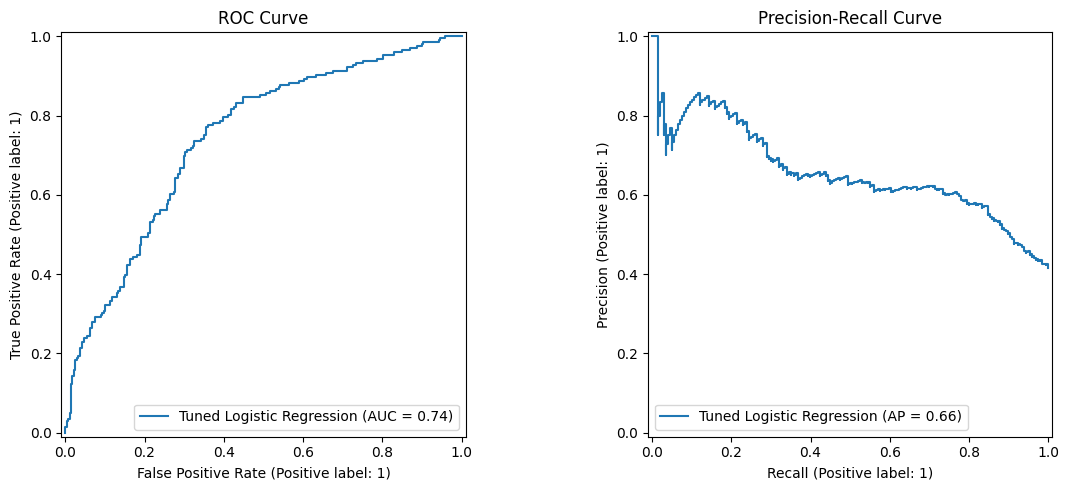

Tuned LR AUC-ROC: 0.743
Tuned LR Average Precision: 0.657


In [16]:
# Use the tuned Logistic Regression best estimator to get probabilities
# We use grid_search_lr.best_estimator_ which was defined in the previous tuning cell
lr_probs = grid_search_lr.best_estimator_.predict_proba(X_dev)[:, 1]

y_dev_binary = (y_dev == 'Pathogenic').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting the tuned LR curves
RocCurveDisplay.from_predictions(y_dev_binary, lr_probs, name='Tuned Logistic Regression', ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_dev_binary, lr_probs, name='Tuned Logistic Regression', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

print("Tuned LR AUC-ROC:", round(roc_auc_score(y_dev_binary, lr_probs), 3))
print("Tuned LR Average Precision:", round(average_precision_score(y_dev_binary, lr_probs), 3))

In [17]:
precisions, recalls, thresholds = precision_recall_curve(y_dev_binary, lr_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = f1_scores.argmax()

best_threshold_f1 = thresholds[best_idx]

recall_target = 0.80
valid_idx = np.where(recalls[:-1] >= recall_target)[0]

best_threshold_recall = thresholds[valid_idx[-1]]

y_dev_pred_thresh = (lr_probs >= best_threshold_recall).astype(int)

print(f"Max-F1 threshold:      {best_threshold_f1:.3f}")
print(f"  Precision: {precisions[best_idx]:.3f}  Recall: {recalls[best_idx]:.3f}")
print()
print(f"Recall >= 0.80 threshold: {best_threshold_recall:.3f}")
print(f"  Precision: {precisions[valid_idx[-1]]:.3f}  Recall: {recalls[valid_idx[-1]]:.3f}")

# Apply recall-constrained threshold
y_dev_pred_thresh = (lr_probs >= best_threshold_recall).astype(int)
print("\nClassification Report at recall-constrained threshold:")
print(classification_report(y_dev_binary, y_dev_pred_thresh,
                             target_names=['Benign', 'Pathogenic']))


Max-F1 threshold:      0.432
  Precision: 0.572  Recall: 0.847

Recall >= 0.80 threshold: 0.455
  Precision: 0.579  Recall: 0.801

Classification Report at recall-constrained threshold:
              precision    recall  f1-score   support

      Benign       0.81      0.59      0.68       277
  Pathogenic       0.58      0.80      0.67       196

    accuracy                           0.68       473
   macro avg       0.69      0.69      0.68       473
weighted avg       0.71      0.68      0.68       473



In [18]:
# Use the BEST estimator from GridSearchCV instead of the initial pipe
best_pipe = grid_search_lr.best_estimator_

lr_probs_test = best_pipe.predict_proba(X_test)[:, 1]
y_test_binary = (y_test == 'Pathogenic').astype(int)

# Apply the threshold optimized on the dev set
y_test_pred_thresh = (lr_probs_test >= best_threshold_recall).astype(int)

print("=== FINAL TEST SET EVALUATION (Tuned Model) ===")
print(f"Recall-Constrained Threshold: {best_threshold_recall:.3f}")
print(classification_report(y_test_binary, y_test_pred_thresh, target_names=['Benign', 'Pathogenic']))
print("AUC-ROC:", round(roc_auc_score(y_test_binary, lr_probs_test), 3))
print("Avg Precision:", round(average_precision_score(y_test_binary, lr_probs_test), 3))

=== FINAL TEST SET EVALUATION (Tuned Model) ===
Recall-Constrained Threshold: 0.455
              precision    recall  f1-score   support

      Benign       0.75      0.64      0.69       255
  Pathogenic       0.61      0.73      0.66       196

    accuracy                           0.68       451
   macro avg       0.68      0.68      0.68       451
weighted avg       0.69      0.68      0.68       451

AUC-ROC: 0.721
Avg Precision: 0.663


In [19]:
# Prepare VUS features
X_vus = df_vus.drop(columns=['Variant', 'Significance', 'Source', 'Annotation', 'Position', 'AlphaMissense_score', 'AlphaMissense_class'], errors='ignore')

available_to_drop = [col for col in to_drop_corr if col in X_vus.columns]
missing_to_drop = set(to_drop_corr) - set(available_to_drop)
if missing_to_drop:
    print(f"Warning: {len(missing_to_drop)} correlated training features were not present in VUS data.")

X_vus = X_vus.drop(columns=available_to_drop)

# Use the BEST estimator for reclassification
best_pipe = grid_search_lr.best_estimator_

vus_probs = best_pipe.predict_proba(X_vus)[:, 1]
vus_pred_labels = np.where(vus_probs >= best_threshold_recall,
                           'Likely Pathogenic', 'Likely Benign')

vus_results = pd.DataFrame({
    'Variant':       df_vus['Variant'].values,
    'P(Pathogenic)': vus_probs.round(3),
    'Prediction':    vus_pred_labels
}).sort_values('P(Pathogenic)', ascending=False)

print(f"\nTotal VUS reclassified as Likely Pathogenic: "
      f"{(vus_pred_labels == 'Likely Pathogenic').sum()} / {len(vus_pred_labels)}")
print("\nTop 20 Predicted Pathogenic VUS:")
display(vus_results.head(20))


Total VUS reclassified as Likely Pathogenic: 347 / 812

Top 20 Predicted Pathogenic VUS:


,Variant,P(Pathogenic),Prediction
727,C779W,0.942,Likely Pathogenic
796,G963R,0.927,Likely Pathogenic
746,C81R,0.926,Likely Pathogenic
671,C641R,0.924,Likely Pathogenic
160,Y1410D,0.908,Likely Pathogenic
159,Y1410C,0.907,Likely Pathogenic
218,G1558R,0.903,Likely Pathogenic
4,C1008R,0.903,Likely Pathogenic
745,G805D,0.898,Likely Pathogenic
464,G2162R,0.890,Likely Pathogenic


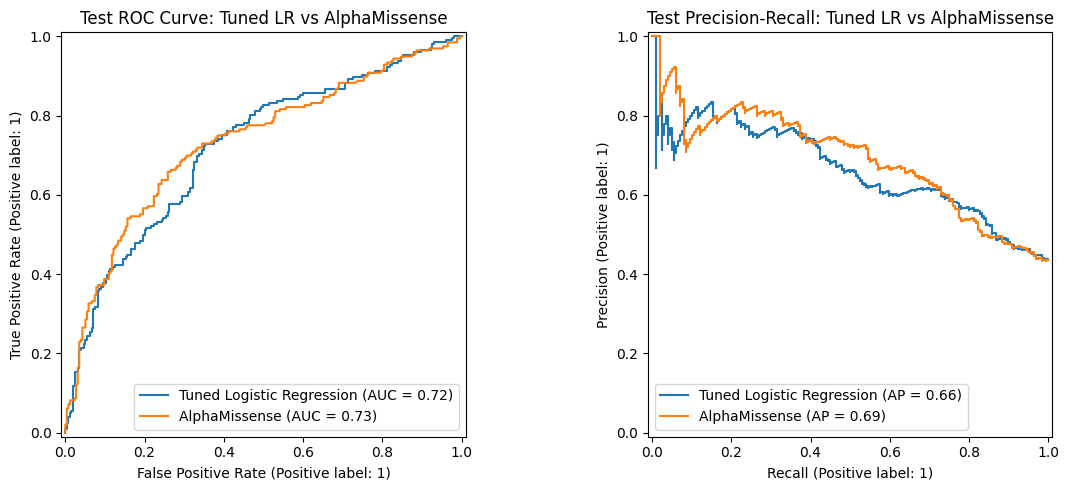

=== TEST SET BENCHMARK VS ALPHAMISSENSE ===
AlphaMissense score column: AlphaMissense_score
Rows compared: 451 / 451 test variants
Tuned LR AUC-ROC: 0.721
AlphaMissense AUC-ROC: 0.732
Tuned LR Average Precision: 0.663
AlphaMissense Average Precision: 0.689


In [20]:

# Ensure AlphaMissense scores are present before benchmarking.
# If scores are in a separate file, merge them into `df` first by variant key.
alpha_col = None
for candidate in ['am_pathogenicity', 'AlphaMissense_score']:
    if candidate in df.columns:
        alpha_col = candidate
        break

if alpha_col is None:
    print("AlphaMissense score column not found. Please merge AlphaMissense scores into df before running this benchmark.")
else:
    # Prerequisites: run the earlier split/training/test-evaluation cells first.
    required_vars = ['df_known', 'temp_idx', 'test_idx', 'grid_search_lr', 'X_test', 'y_test_binary']
    missing_vars = [v for v in required_vars if v not in globals()]
    if missing_vars:
        print(f"Missing prerequisite variable(s): {missing_vars}. Run prior model training/evaluation cells first.")
    else:
        # Rebuild exact known-label test indices using the same split objects and `test_idx`
        df_known_temp = df_known.iloc[temp_idx]
        test_known_indices = df_known_temp.iloc[test_idx].index

        # Tuned LR probabilities on the same test rows
        best_pipe = grid_search_lr.best_estimator_
        lr_probs_test = best_pipe.predict_proba(X_test)[:, 1]

        # AlphaMissense scores aligned to those exact test indices
        alpha_raw_test = df_known.loc[test_known_indices, alpha_col]
        alpha_probs_test = pd.to_numeric(alpha_raw_test, errors='coerce')
        # Counts present-but-non-numeric values that became NaN after coercion.
        unparseable_alpha_count = (alpha_raw_test.notna() & alpha_probs_test.isna()).sum()
        if unparseable_alpha_count > 0:
            print(f"Warning: {unparseable_alpha_count} AlphaMissense test score(s) could not be parsed as numeric and were dropped.")

        # Align with y_test_binary and warn if indices differ
        if not alpha_probs_test.index.equals(y_test_binary.index):
            print("Warning: AlphaMissense/test label indices are not perfectly aligned; reindexing to y_test_binary index.")
        am_prob_aligned = alpha_probs_test.reindex(y_test_binary.index)

        # Build comparable frame and drop missing AlphaMissense values
        comp_df = pd.DataFrame({
            'y_true': y_test_binary,
            'lr_prob': lr_probs_test,
            'am_prob': am_prob_aligned
        }).dropna(subset=['am_prob'])

        if comp_df.empty:
            print("No overlapping non-null AlphaMissense scores on test rows. Please check merge keys/source file.")
        else:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            RocCurveDisplay.from_predictions(comp_df['y_true'], comp_df['lr_prob'],
                                             name='Tuned Logistic Regression', ax=axes[0])
            RocCurveDisplay.from_predictions(comp_df['y_true'], comp_df['am_prob'],
                                             name='AlphaMissense', ax=axes[0])
            axes[0].set_title('Test ROC Curve: Tuned LR vs AlphaMissense')

            PrecisionRecallDisplay.from_predictions(comp_df['y_true'], comp_df['lr_prob'],
                                                    name='Tuned Logistic Regression', ax=axes[1])
            PrecisionRecallDisplay.from_predictions(comp_df['y_true'], comp_df['am_prob'],
                                                    name='AlphaMissense', ax=axes[1])
            axes[1].set_title('Test Precision-Recall: Tuned LR vs AlphaMissense')

            plt.tight_layout()
            plt.show()

            print('=== TEST SET BENCHMARK VS ALPHAMISSENSE ===')
            print(f"AlphaMissense score column: {alpha_col}")
            print(f"Rows compared: {len(comp_df)} / {len(y_test_binary)} test variants")
            print(f"Tuned LR AUC-ROC: {roc_auc_score(comp_df['y_true'], comp_df['lr_prob']):.3f}")
            print(f"AlphaMissense AUC-ROC: {roc_auc_score(comp_df['y_true'], comp_df['am_prob']):.3f}")
            print(f"Tuned LR Average Precision: {average_precision_score(comp_df['y_true'], comp_df['lr_prob']):.3f}")
            print(f"AlphaMissense Average Precision: {average_precision_score(comp_df['y_true'], comp_df['am_prob']):.3f}")


In [21]:

# VUS disagreement analysis between tuned LR and AlphaMissense
# AlphaMissense threshold from paper: score > 0.564 => pathogenic-like; otherwise benign-like
# Source: AlphaMissense publication (Cheng et al., Science, 2023).
ALPHAMISSENSE_PATHOGENIC_THRESHOLD = 0.564
alpha_vus_col = None
for candidate in ['am_pathogenicity', 'AlphaMissense_score']:
    if candidate in df_vus.columns:
        alpha_vus_col = candidate
        break

if alpha_vus_col is None:
    print("AlphaMissense score column not found in df_vus. Please merge AlphaMissense VUS scores before disagreement analysis.")
elif 'best_threshold_recall' not in globals():
    print("best_threshold_recall is not defined. Run the threshold-optimization cell before this disagreement analysis.")
elif 'grid_search_lr' not in globals() or 'X_vus' not in globals():
    print("Missing prerequisite variable(s): ['grid_search_lr' and/or 'X_vus']. Run prior model/VUS preparation cells first.")
else:
    best_pipe = grid_search_lr.best_estimator_
    vus_probs = best_pipe.predict_proba(X_vus)[:, 1]
    lr_vus_pred = np.where(vus_probs >= best_threshold_recall, 'Likely Pathogenic', 'Likely Benign')

    alpha_vus_raw = df_vus[alpha_vus_col]
    alpha_vus_scores = pd.to_numeric(alpha_vus_raw, errors='coerce')
    unparseable_vus_alpha_count = (alpha_vus_raw.notna() & alpha_vus_scores.isna()).sum()
    if unparseable_vus_alpha_count > 0:
        print(f"Warning: {unparseable_vus_alpha_count} AlphaMissense VUS score(s) could not be parsed as numeric and were dropped.")

    vus_compare = pd.DataFrame({
        'Variant': df_vus['Variant'],
        'LR_score': np.round(vus_probs, 3),
        'LR_prediction': lr_vus_pred,
        'AlphaMissense_score': alpha_vus_scores
    }).dropna(subset=['AlphaMissense_score'])
    vus_compare['AlphaMissense_prediction'] = np.where(
        vus_compare['AlphaMissense_score'] > ALPHAMISSENSE_PATHOGENIC_THRESHOLD,
        'Likely Pathogenic',
        'Likely Benign'
    )

    disagreement_df = vus_compare[vus_compare['LR_prediction'] != vus_compare['AlphaMissense_prediction']].copy()
    disagreement_df['AlphaMissense_score'] = disagreement_df['AlphaMissense_score'].round(3)

    print(f"Total VUS compared (non-null AlphaMissense): {len(vus_compare)}")
    print(f"Total LR vs AlphaMissense disagreements: {len(disagreement_df)}")
    display(disagreement_df.sort_values('LR_score', ascending=False))


Total VUS compared (non-null AlphaMissense): 812
Total LR vs AlphaMissense disagreements: 204


,Variant,LR_score,LR_prediction,AlphaMissense_score,AlphaMissense_prediction
101,R1055W,0.871,Likely Pathogenic,0.178,Likely Benign
3478,H776R,0.815,Likely Pathogenic,0.432,Likely Benign
3472,Y773C,0.815,Likely Pathogenic,0.367,Likely Benign
3642,G863R,0.807,Likely Pathogenic,0.557,Likely Benign
3121,D596Y,0.783,Likely Pathogenic,0.517,Likely Benign
...,...,...,...,...,...
2498,F251L,0.294,Likely Benign,0.617,Likely Pathogenic
3599,M843I,0.292,Likely Benign,0.662,Likely Pathogenic
952,Q1513H,0.287,Likely Benign,0.629,Likely Pathogenic
2235,F216L,0.265,Likely Benign,0.858,Likely Pathogenic
